# Objective

The objective of this project is to predict weather conditions using Logistic Regression based on climatic features such as precipitation, temperature, and wind.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wp_data = pd.read_csv(r"C:\Users\harsh kasana\Downloads\seattle-weather (1).csv")

# Data Dictionary

| Feature Name | Description |
|---|---|
| date | Date on which weather data was recorded |
| precipitation | Amount of rainfall or precipitation recorded (in inches) |
| temp_max | Maximum temperature recorded for the day |
| temp_min | Minimum temperature recorded for the day |
| wind | Wind speed recorded for the day |
| weather | Target variable representing weather condition categories such as rain, sun, fog, drizzle, and snow |
| year | Year extracted from the date column |
| month | Month extracted from the date column |
| day | Day extracted from the date column |

In [3]:
wp_data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
wp_data.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


In [5]:
wp_data.shape

(1461, 6)

In [6]:
wp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [7]:
wp_data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [8]:
wp_data.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [9]:
wp_data.duplicated().sum()

np.int64(0)

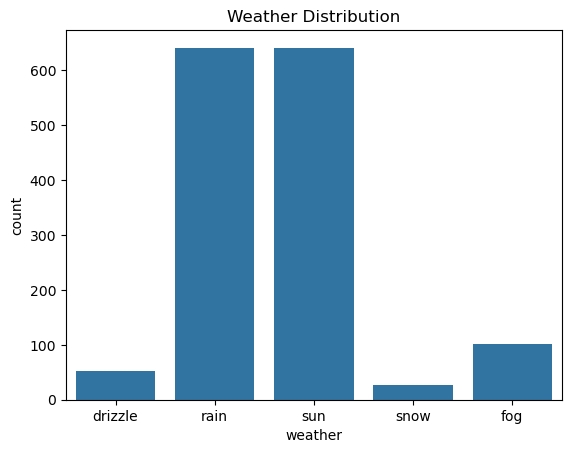

In [10]:
sns.countplot(x="weather",data=wp_data)
plt.title("Weather Distribution")
plt.show()

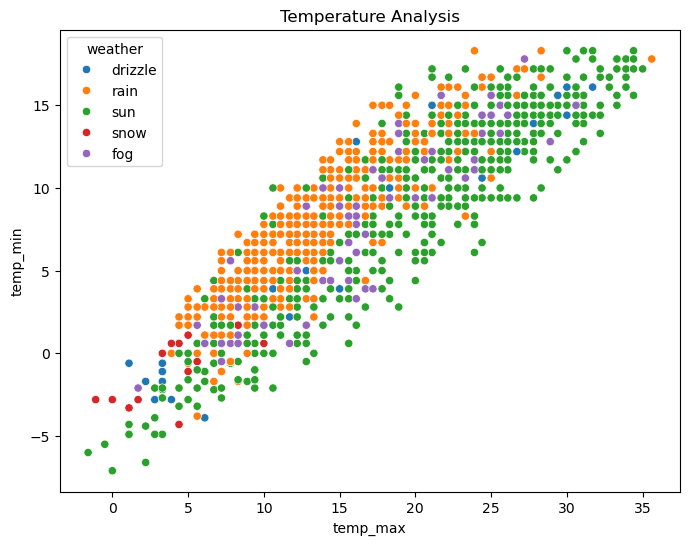

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="temp_max", y="temp_min", hue="weather", data=wp_data)
plt.title("Temperature Analysis")
plt.show()

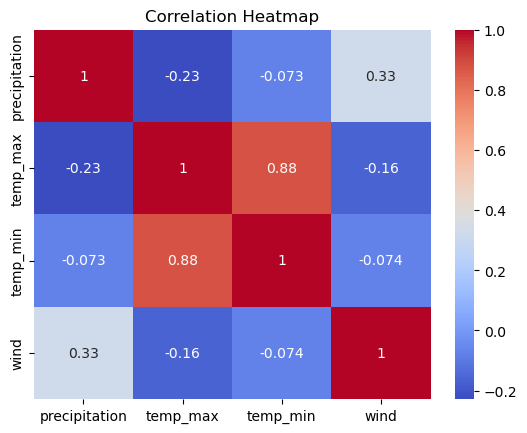

In [14]:
sns.heatmap(wp_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

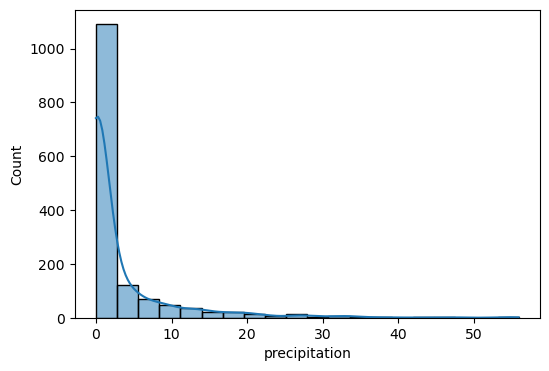

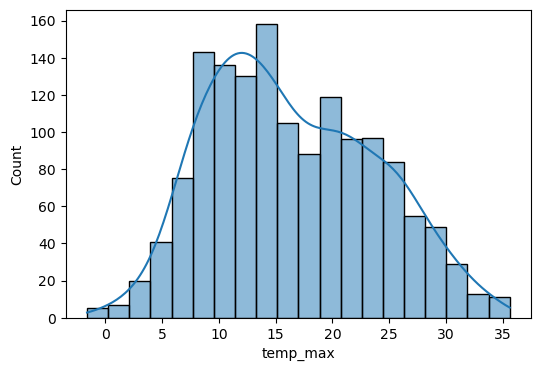

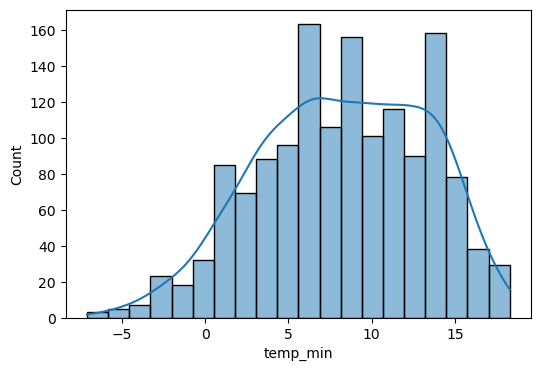

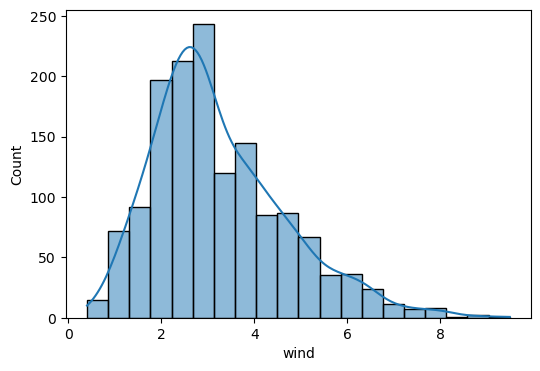

In [15]:
numeric_column=["precipitation","temp_max","temp_min","wind"]
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(wp_data[col],kde=True,bins=20)

# Encoding 

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
wp_data["weather"] = le.fit_transform(wp_data["weather"])


In [32]:
wp_data["date"] = pd.to_datetime(wp_data["date"])
#Extracting Features
wp_data["year"] = wp_data["date"].dt.year
wp_data["month"] = wp_data["date"].dt.month
wp_data["day"] = wp_data["date"].dt.day
wp_data.drop("date", axis=1, inplace=True)

In [22]:
X = wp_data.drop("weather", axis=1)
y = wp_data["weather"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Feature Scaling

Feature scaling is performed using StandardScaler to normalize the feature values.

Scaling improves the performance of Logistic Regression because the algorithm is sensitive to feature magnitude.

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for classification tasks.

In this project, Logistic Regression is used to classify different weather conditions based on environmental features.

In [40]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
y_pred = LR.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7952218430034129


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       1.00      0.04      0.08        25
           2       0.87      0.88      0.88       120
           3       1.00      0.12      0.22         8
           4       0.74      0.95      0.83       131

    accuracy                           0.80       293
   macro avg       0.72      0.40      0.40       293
weighted avg       0.80      0.80      0.74       293



C:\Users\harsh kasana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\harsh kasana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\harsh kasana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Observation

The classification report shows that the Logistic Regression model achieved 80% accuracy in predicting weather conditions.

The model showed strong performance for:
- Class 2 with an F1-score of 0.88
- Class 4 with an F1-score of 0.83

However, the model struggled to classify minority classes such as 0 and 3 due to class imbalance and fewer training samples.

Overall, the model demonstrates good predictive capability for common weather conditions but may require balancing techniques or advanced models to improve minority class prediction.

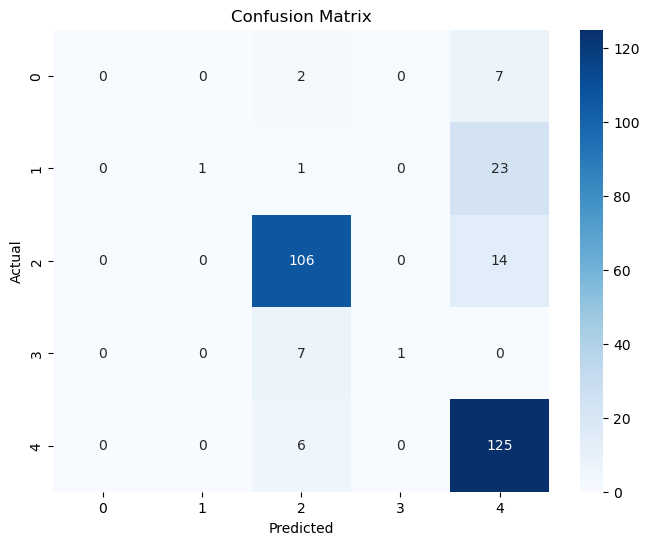

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Conclusion

The Logistic Regression model successfully classified weather conditions using climatic data.

The model achieved good predictive performance and demonstrated the effectiveness of machine learning in weather classification problems.